In [3]:
import matplotlib.pyplot as plt
import numpy as np
import mysql.connector

In [6]:
plt.rcParams['font.family'] = 'Malgun Gothic'

In [7]:
# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='1234',  # 실제 비밀번호로 변경하세요
    database='sys'
)

In [8]:
# 커서(cursor) 객체 생성 (SQL 실행을 위한 객체)
cursor = conn.cursor()

In [13]:
# SQL 쿼리 정의: 지역별 캠핑장 개수 조회
query = '''
SELECT SUBSTR(지번주소, 1, INSTR(지번주소, ' ')) AS LOCATION,
	   count(*)
FROM camping_info
GROUP BY LOCATION;
'''

In [14]:
# SQL 실행
cursor.execute(query)

In [15]:
# 결과 데이터를 가져옴 (튜플 리스트 형태로 반환됨)
data = cursor.fetchall()

In [16]:
data

[('서울특별시 ', 35),
 ('부산광역시 ', 18),
 ('대구광역시 ', 50),
 ('인천광역시 ', 130),
 ('광주광역시 ', 7),
 ('대전광역시 ', 16),
 ('울산광역시 ', 30),
 ('경기도 ', 1113),
 ('강원특별자치도 ', 1138),
 ('충청북도 ', 298),
 ('충청남도 ', 474),
 ('전북특별자치도 ', 180),
 ('전라남도 ', 276),
 ('경상북도 ', 552),
 ('경상남도 ', 348),
 ('세종특별자치시 ', 9),
 ('제주특별자치도 ', 72)]

In [17]:
# 데이터베이스 연결 종료
conn.close()

In [18]:
# 지역명(label)과 캠핑장 개수(ratio)를 저장할 리스트 초기화
label = []
ratio = []

# SQL 조회 결과를 반복문을 통해 리스트에 저장
for lb, cnt in data:
    label.append(lb)
    ratio.append(cnt)

<function matplotlib.pyplot.show(close=None, block=None)>

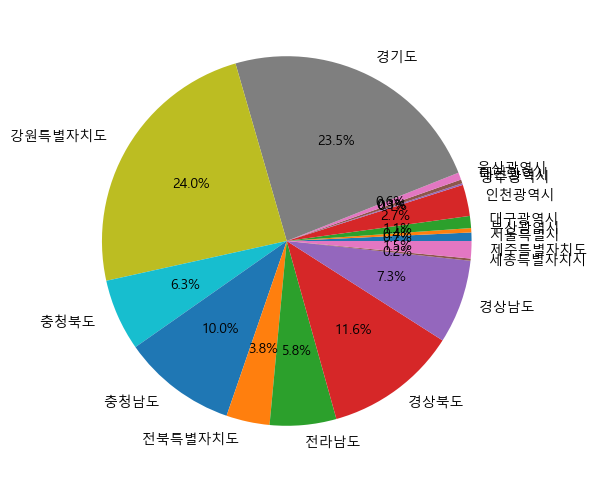

In [19]:
# 원형(파이) 차트 그리기
plt.figure(figsize=(10, 6))
plt.pie(ratio, labels=label, autopct='%.1f%%')
plt.show

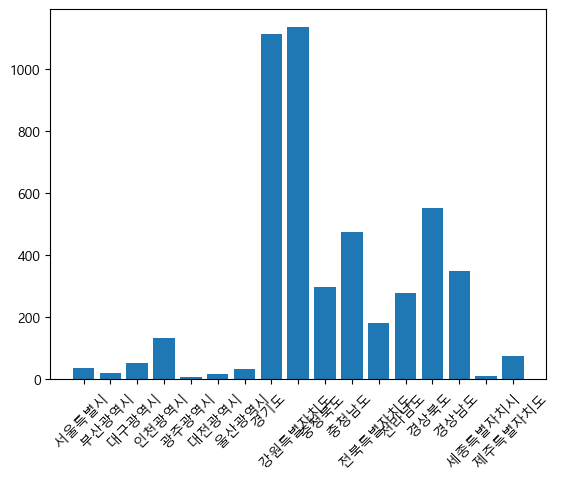

In [20]:
# 막대그래프 그리기
x = np.arange(len(data))   # X축 좌표 (0부터 시작하는 정수 배열)
plt.bar(x, ratio)
plt.xticks(x, label)
plt.xticks(rotation=45)
plt.show()